14 · Public transport (GTFS)

city2graph's transport module turns a GTFS feed into a network:

- `load_gtfs()` opens the zip as queryable tables, geometry on stops and
  shapes.
- `travel_summary_graph()` aggregates scheduled trips into stop→stop edges
  with a service frequency and a mean travel time for the period asked for.

Those edges are scheduled service, not physical connection: two adjacent
stops with no line joining them have no edge, however close. No internet
needed: the São Paulo feed ships with the repository.

## 0 · Setup

In [1]:
import pathlib
import sys


def find_repo():
    """Locate the SciGraphs repository, without relying on the cwd.

    In a normal Jupyter the kernel starts per notebook with the cwd set to its
    folder. Not here: the kernel lives inside Blender and existed before you
    opened anything, so the cwd is wherever Blender was launched from. What the
    extension does know is which folder it is serving to JupyterLab.
    """
    candidates = []
    try:
        import bpy
        prefs = bpy.context.preferences.addons[
            "bl_ext.user_default.jupyter_blender"].preferences
        candidates.append(pathlib.Path(bpy.path.abspath(prefs.notebook_dir)))
    except Exception:
        pass
    candidates.append(pathlib.Path.cwd())

    for base in candidates:
        for directory in (base, *base.parents):
            if (directory / "SciGraphs" / "api" / "graphs.py").is_file():
                return directory

    raise RuntimeError(
        "Cannot find the SciGraphs repository. Point at it by hand:\n"
        "    sys.path.insert(0, '/path/to/SciGraphs-1/notebooks/tools')")


sys.path.insert(0, str(find_repo() / "notebooks" / "tools"))

import bpy
import city2graph as c2g

# `nb` must import first: it puts this repository on sys.path, so the
# `SciGraphs` import below reads this tree, not the copy Blender installed.
import nb
from nb import check

from SciGraphs import api as sg

FEED = nb.repo("examples", "GTFS", "sao_paulo.zip")
print("feed:", nb.rel(FEED), f"({FEED.stat().st_size / 1e6:.0f} MB)")
check("the feed exists", FEED.exists())

feed: examples/GTFS/sao_paulo.zip (14 MB)
[PASS] the feed exists


True

## 1 · Load the feed

`load_gtfs()` returns a DuckDB connection. Nothing is read into memory, so
million-row feeds stay queryable in Blender.

In [2]:
con = c2g.load_gtfs(FEED)

tables = [row[0] for row in con.execute("SHOW TABLES").fetchall()]
print(f"{len(tables)} tables:\n")
for table in tables:
    n = con.execute(f"SELECT count(*) FROM {table}").fetchone()[0]
    print(f"  {table:<18} {n:>9,}")

10 tables:

  agency                     1
  calendar                   6
  fare_attributes            6
  fare_rules             5,395
  frequencies           40,186
  routes                 1,352
  shapes             1,137,068
  stop_times            98,862
  stops                 22,143
  trips                  2,257


Check the calendar first: a date range outside the feed's
coverage returns an empty graph.

In [3]:
calendar_df = con.execute(
    "SELECT service_id, start_date, end_date, monday, saturday, sunday "
    "FROM calendar ORDER BY service_id").fetchdf()
print(calendar_df.to_string(index=False))

date_range = con.execute("SELECT min(start_date), max(end_date) FROM calendar").fetchone()
print(f"\nfeed coverage: {date_range[0]} … {date_range[1]}")

service_id start_date end_date monday saturday sunday
       USD   20231001 20261201      1        1      1
       US_   20231001 20261201      1        1      0
       U__   20231001 20261201      1        0      0
       _SD   20231001 20261201      0        1      1
       _S_   20231001 20261201      0        1      0
       __D   20231001 20261201      0        0      1

feed coverage: 20231001 … 20261201


## 2 · The stops

`stop_lat`/`stop_lon` are already point geometry with a CRS: from here on,
an ordinary GeoDataFrame.

In [4]:
stops = con.execute("SELECT * FROM stops LIMIT 5").fetchdf()
print(list(stops.columns))
stops[["stop_id", "stop_name", "stop_lat", "stop_lon"]].head()

['stop_id', 'stop_name', 'stop_desc', 'stop_lat', 'stop_lon', 'geometry']


,stop_id,stop_name,stop_lat,stop_lon
0,18848,Clínicas,-23.554022,-46.671108
1,18849,Vila Madalena,-23.546498,-46.691141
2,18850,Consolação,-23.558094,-46.660205
3,18851,Conceição,-23.635039,-46.641239
4,18852,Jabaquara,-23.646033,-46.641028


## 3 · Service network: `travel_summary_graph()`

Every scheduled trip in the period becomes stop→stop edges:

- `frequency`: how many services run
- `travel_time_sec`: mean run time between the two stops

Below, the morning peak.

In [5]:
import time

t0 = time.time()
stops_gdf, segments_gdf = c2g.travel_summary_graph(
    con,
    start_time="06:00:00",
    end_time="10:00:00",
)
print(f"built in {time.time() - t0:.1f} s")
print(f"stops {len(stops_gdf):,}, segments {len(segments_gdf):,}")
print(f"edge columns: {list(segments_gdf.columns)}")
print(f"edge index  : {segments_gdf.index.names}")

built in 0.6 s
stops 22,143, segments 10,311
edge columns: ['frequency', 'geometry', 'travel_time_sec']
edge index  : ['from_stop_id', 'to_stop_id']


Many more stops than segments: most have no service in this
window and end up isolated. That is what a relation defined by service, not
proximity, looks like.

In [6]:
import numpy as np

degree = np.zeros(len(stops_gdf), dtype=int)
position = {sid: i for i, sid in enumerate(stops_gdf.index)}
for source, target in segments_gdf.index:
    if source in position:
        degree[position[source]] += 1
    if target in position:
        degree[position[target]] += 1

isolated = int((degree == 0).sum())
print(f"stops with service 06:00-10:00 : {len(stops_gdf) - isolated:,}")
print(f"stops isolated in this window  : {isolated:,}")

print("\nfrequency per segment:")
print(segments_gdf["frequency"].describe().to_string())
print("\ntravel time (s):")
print(segments_gdf["travel_time_sec"].describe().to_string())

stops with service 06:00-10:00 : 9,386
stops isolated in this window  : 12,757

frequency per segment:
count    1.031100e+04
mean     1.364147e+05
std      1.642531e+05
min      8.270000e+02
25%      3.937200e+04
50%      8.106000e+04
75%      1.609620e+05
max      1.317607e+06

travel time (s):
count    10311.000000
mean       119.782488
std         42.971214
min         53.000000
25%         97.000000
50%        109.000000
75%        130.295819
max        560.000000


## 4 · Into Blender

Keep the component with service: 22,000 loose vertices add nothing to the
viewport and do slow Geometry Nodes.

In [7]:
with_service = stops_gdf[degree > 0].copy()
valid_segments = segments_gdf[
    segments_gdf.index.get_level_values(0).isin(with_service.index)
    & segments_gdf.index.get_level_values(1).isin(with_service.index)
].copy()

print(f"{len(with_service):,} stops, {len(valid_segments):,} segments")

sg.graphs.clear_scene(keep_anchor=False)
anchor = sg.graphs.anchor_from(with_service, scale=0.001, name="Anchor_GTFS")

obj_network = sg.graphs.from_gdf(
    with_service, valid_segments,
    name="GTFS_Service_06_10", ref=anchor, coll="C2G_Transport",
    markers={"graph_type": "travel_summary_graph",
             "gtfs_feed": FEED.name,
             "window": "06:00-10:00"})

print(sg.graphs.summary(obj_network))
check("the service network is in the scene", obj_network is not None)

9,386 stops, 10,311 segments
{'object': 'GTFS_Service_06_10', 'type': 'MESH', 'num_nodes': 9386, 'num_edges': 10308, 'is_directed': False, 'vertices': 9386, 'mesh_edges': 10308, 'attributes': ['position', '.edge_verts', '.corner_vert', '.corner_edge', 'node_id', 'edge_frequency', 'edge_travel_time_sec'], 'graph_type': 'travel_summary_graph'}
[PASS] the service network is in the scene


True

EEVEE figures: real geometry and materials, composable with the
rest of the scene. Unlike the neighborhood notebooks, nothing is composed
under this one. At tens of kilometers across a building footprint is under a
pixel, several hundred thousand of them would have to be downloaded and
extruded for a uniform gray wash, and a flat plane adds a dark rectangle and
no information.

Orthographic, straight down (`render_eevee`'s default), `look='ink'` as in
notebooks 00 to 07: near-black backdrop, turbo ramp on `edge_frequency`,
buses per hour in the 06:00-10:00 window, dark blue for the quiet lines to
red for the busiest.

`clip_high_pct=98`: frequency is heavily skewed, so a few central segments
carrying many times the median would take the top of the ramp and collapse
every other line into the bottom stop. The 98th percentile spends the scale on
the other 98 %.

Numeric columns become mesh attributes: `node_*` on POINT,
`edge_*` on EDGE.

In [8]:
for name, domain, dtype in sg.graphs.attributes(obj_network):
    print(f"  {name:<28} {domain:<7} {dtype}")

  position                     POINT   FLOAT_VECTOR
  .edge_verts                  EDGE    INT32_2D
  .corner_vert                 CORNER  INT
  .corner_edge                 CORNER  INT
  node_id                      POINT   INT
  edge_frequency               EDGE    FLOAT
  edge_travel_time_sec         EDGE    FLOAT


`edge_frequency` is on the EDGE domain, so the colormap lands on
the tubes. `color_graph()` re-domains it onto the points at the head of the
Geometry Nodes tree, since it cannot survive Mesh to Curve → Curve to Mesh.

edge_frequency domain: EDGE
  Promoted 2 edge attribute(s) to point domain for GN propagation
Info: Geometry Nodes modifier added
Info: Attribute -> edge_frequency  ·  edge_frequency -> turbo [log]  [827 … 6.889e+05] on Point


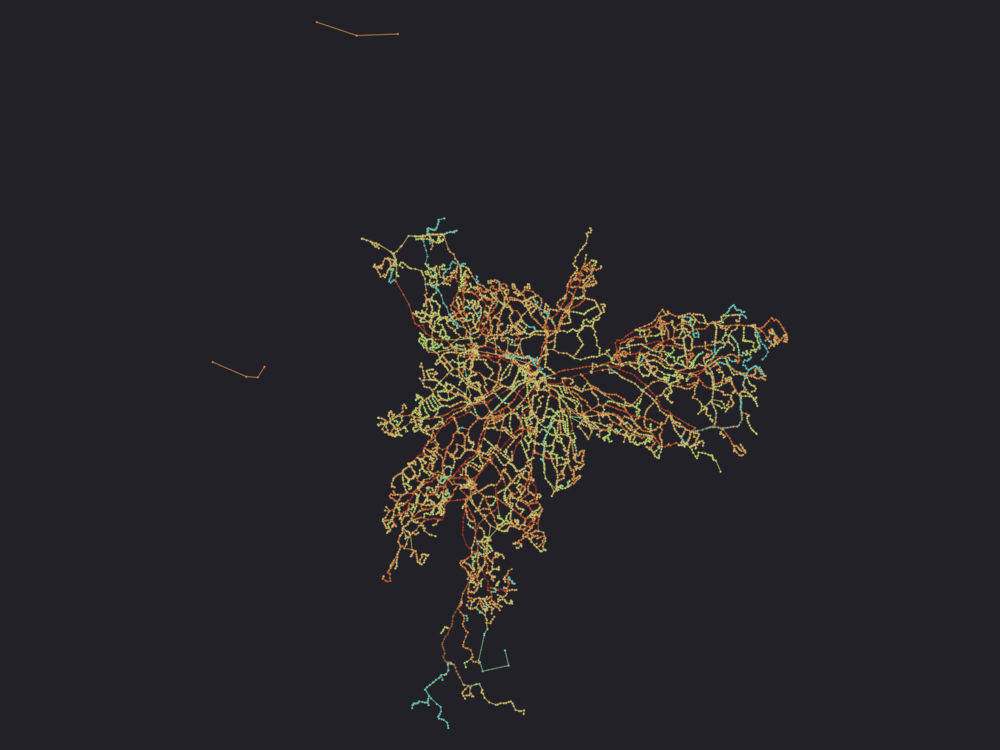

[PASS] 1_service_06_10.png legible — 6.1% ink (healthy range 0.5–60%)


In [9]:
print("edge_frequency domain:",
      sg.render.attribute_domain(obj_network, "edge_frequency"))

nb.figure(obj_network, "renders/14_gtfs/1_service_06_10",
          look='ink', color_attribute="edge_frequency",
          clip_high_pct=98)

## 5 · The same coloring in the viewport

`sg.graphs.color_by()` drives the same operator as `color_graph()`, minus the
percentile clipping (a `color_graph()` argument).

In [10]:
sg.graphs.visualize(obj_network, node_size=0.008, edge_thickness=0.003)
result, message = sg.graphs.color_by(obj_network, "edge_frequency", colormap="inferno")
print(message)
sg.graphs.frame(obj_network)

  Promoted 2 edge attribute(s) to point domain for GN propagation
Info: Geometry Nodes modifier added
Info: Attribute -> edge_frequency  ·  edge_frequency -> inferno [log]  [827 … 6.889e+05] on Point
edge_frequency -> inferno


bpy.data.objects['GTFS_Service_06_10']

## 6 · Origin-destination pairs: `get_od_pairs()`

The other output: pairs of stops connected by the same trip rather than
consecutive segments. Feeds notebook 15's flow analysis.

In [11]:
t0 = time.time()
od = c2g.get_od_pairs(
    con,
    start_date=str(date_range[0]),
    end_date=str(date_range[0]),   # a single day: keeps the size manageable
    include_geometry=True,
    directed=False,
)
print(f"{time.time() - t0:.1f} s")

# Unlike travel_summary_graph(), this returns one GeoDataFrame of pairs, not
# the (nodes, edges) tuple.
print(f"OD pairs: {len(od):,}")
print("columns:", list(od.columns))
od.head(3)

6.5 s
OD pairs: 77,374
columns: ['trip_id', 'service_id', 'orig_stop_id', 'dest_stop_id', 'date', 'departure_ts', 'arrival_ts', 'travel_time_sec', 'geometry']


,trip_id,service_id,orig_stop_id,dest_stop_id,date,departure_ts,arrival_ts,travel_time_sec,geometry
0,1012-10-0,USD,30003038,301646,2023-10-01,2023-10-01 07:28:00,2023-10-01 07:26:40,80.0,"LINESTRING (-46.80332 -23.44653, -46.80044 -23..."
1,1012-10-0,USD,301671,301701,2023-10-01,2023-10-01 07:38:40,2023-10-01 07:40:00,80.0,"LINESTRING (-46.80574 -23.43718, -46.80415 -23..."
2,1012-10-0,USD,301672,301768,2023-10-01,2023-10-01 07:36:00,2023-10-01 07:37:20,80.0,"LINESTRING (-46.80704 -23.43923, -46.80593 -23..."


> **Note.** `bpy.ops.scigraphs.c2g_get_od_pairs()` does not
> call `get_od_pairs()`; its own SQL query, for memory reasons documented in
> the code, joins on `stop_sequence = stop_sequence + 1` and so assumes
> consecutive numbering. The GTFS spec only requires `stop_sequence` to
> increase, and many feeds number 0, 10, 20… With one of those the operator
> returns zero pairs while the direct call works. This feed numbers one by
> one, so the two agree.

## 7 · Compare with the SciGraphs operator

The operators read `scene.city2graph`, so write there first.

In [12]:
scene = bpy.context.scene
props = scene.city2graph

props.c2g_gtfs_path = str(FEED)
props.c2g_gtfs_create_stops = True
props.c2g_gtfs_create_routes = True

result = bpy.ops.scigraphs.c2g_import_gtfs(filepath=str(FEED))
print("c2g_import_gtfs ->", result)
print("scene['c2g_gtfs_loaded'] =", scene.get("c2g_gtfs_loaded"))
print("registered tables        =", scene.get("c2g_gtfs_tables"))

Loading GTFS data from examples/GTFS/sao_paulo.zip
GTFS loaded with tables: agency, calendar, fare_attributes, fare_rules, frequencies, routes, shapes, stop_times, stops, trips
Stops: 22143
Routes: 1352
Info: Loading GTFS data from examples/GTFS/sao_paulo.zip
Info: GTFS data loaded successfully
c2g_import_gtfs -> {'FINISHED'}
scene['c2g_gtfs_loaded'] = True
registered tables        = ['agency', 'calendar', 'fare_attributes', 'fare_rules', 'frequencies', 'routes', 'shapes', 'stop_times', 'stops', 'trips']


In [13]:
# These are enums over the dates the import wrote into
# scene["c2g_gtfs_dates"], so only those values assign. Feeds whose calendar
# has no empty option raise an enum TypeError on "".
dates = list(scene.get("c2g_gtfs_dates") or [])
print(f"{len(dates)} dates available: {dates[0]} … {dates[-1]}")
props.gtfs_calendar_start = dates[0]
props.gtfs_calendar_end = dates[min(6, len(dates) - 1)]   # one week

result = bpy.ops.scigraphs.c2g_travel_summary_graph()
print("c2g_travel_summary_graph ->", result)

objs_gtfs = [o for o in bpy.data.objects if o.get("is_travel_graph")]
for obj in objs_gtfs:
    print(" ", sg.graphs.summary(obj))

check("the operator produced a travel graph", len(objs_gtfs) > 0)

367 dates available: 20231001 … 20241001
Creating travel summary graph (start=None, end=None, cal_start=20231001, cal_end=20231007)...

Creating graph object with 22,143 nodes...
  Coordinates applied for 22143/22143 nodes in 0.01s
  Vertices created in 0.02s
  Creating edges: 34% (10,000/29,618)
  Creating edges: 68% (20,000/29,618)
  29,602 edges created in 0.02s
  16 self-loops removed
  Mesh conversion in 0.00s
  Object created in 0.00s
DataFrame columns: ['source', 'target', 'frequency', 'travel_time_sec']
DataFrame shape: (29618, 4)
Source column: source, Target column: target
Number of mesh vertices: 22143
Number of mesh edges: 29602
Processing column 'frequency': int64
  Created edge attribute 'edge_frequency'
  Created vertex attributes for 'frequency': sum, mean, min, max, count
Processing column 'travel_time_sec': float64
  Created edge attribute 'edge_travel_time_sec'
  Created vertex attributes for 'travel_time_sec': sum, mean, min, max, count
Imported 2 attribute columns


True

Next to the graph from cell 4. Same look, same attribute where
the operator wrote one: a comparison in which the palette also changes is not
a comparison. The frequency column does not always come through, so it is
looked up; absent, the look's neutral applies.

coloring by: edge_frequency
  Promoted 2 edge attribute(s) to point domain for GN propagation
Info: Geometry Nodes modifier added
Info: Attribute -> edge_frequency  ·  edge_frequency -> turbo [log]  [5 … 6172] on Point


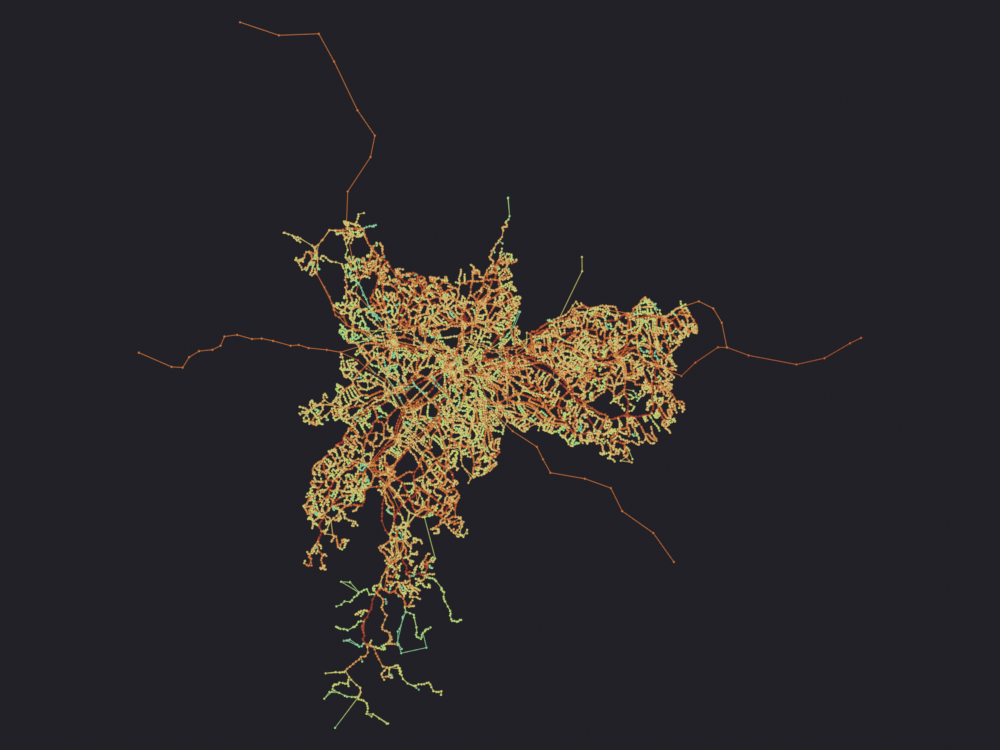

[PASS] 2_operator_Travel_Summary_Graph.png legible — 8.8% ink (healthy range 0.5–60%)


In [14]:
for obj in objs_gtfs[:1]:
    attribute = ("edge_frequency"
                 if sg.render.attribute_domain(obj, "edge_frequency") else None)
    print("coloring by:", attribute or "(nothing: the operator wrote no frequency)")
    nb.figure(obj, f"renders/14_gtfs/2_operator_{obj.name}",
              look='ink', color_attribute=attribute,
              clip_high_pct=98)

The counts need not match cell 3: `start_time`/`end_time` are
not exposed in the panel, only the calendar range, so no time-of-day filter
here. A difference of parameters, not of implementation.

## 8 · Save

In [15]:
out_dir = nb.out("02_gtfs")
out_dir.mkdir(parents=True, exist_ok=True)

sg.graphs.save_gdf(with_service, out_dir / "stops_with_service.gpkg")
sg.graphs.save_gdf(valid_segments, out_dir / "service_segments.gpkg")

print("written to", nb.rel(out_dir))
for f in sorted(out_dir.iterdir()):
    print("  ", f.name, f"{f.stat().st_size / 1e3:.0f} kB")

written to notebooks/out/02_gtfs
   paradas_con_servicio.gpkg 1946 kB
   service_segments.gpkg 1909 kB
   stops_with_service.gpkg 1946 kB
   tramos_servicio.gpkg 1909 kB


## 9 · Try it with your own feed

- <https://transitfeeds.com>, <https://mobilitydatabase.org>: aggregators
- <https://data.bus-data.dft.gov.uk>: United Kingdom
- <https://www.mta.info/developers>: New York

Change `FEED` in cell 0 and re-run. A feed using `calendar_dates.txt` rather
than `calendar.txt` leaves the calendar cell empty; the graph builds anyway.

In [16]:
con.close()
print("connection closed")

connection closed


## Rendering

Notebook 13 covers `draw_eevee()`. PNGs land in `notebooks/out/renders/`.

> Vulkan warning, for the SciGraphs engine notebooks 17 and 06 keep for edge
> sparsification: on Blender's Vulkan backend (the default on Linux)
> `gpu.state.point_size_set` does nothing for the add-on's shaders, so `POINT`
> and `DISK` nodes come out 1 pixel wide. Start Blender with
> `--gpu-backend opengl` for any render you mean to look at.

## Summary

| Function | Result |
|---|---|
| `load_gtfs()` | DuckDB connection with geometry |
| `travel_summary_graph()` | `GTFS_Service_06_10` |
| `get_od_pairs()` | GeoDataFrame for notebook 15 |

Next: **03 · Mobility (OD matrices)**.